# EDA: Regression Modeling

En esta notebook se analiza el dataset geospatial para: 

- Entender la distribución de las variables
- Identificar relaciones con la variable objetivo (`tasa_delitos`)
- Localizar redundancia de información
- Definir:
    - Transformaciones necesarias
    - Estrategia de escalado
    - Encoding
    - Selección inicial de variables

Este análisis será de utilidad para la construcción de modelos de **regresion**.

## Setup

In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [358]:
from incidencia_delictiva.config import PROCESSED_DATA_DIR as processed_dir
from incidencia_delictiva.config import PROJ_ROOT as root

In [359]:
# config
sns.set(style='whitegrid')

Utilizaremos el dataset [*geospatial*](../docs/data/dataset_geospatial.md)\*. Este conjunto de datos **extiende** el dataset [*baseline*](../docs/data/dataset_baseline.md) incorporando información sobre estructura territorial, proximidad y dependencia espacial entre municipios.


\* La construcción de este fue documentado en la libreta [`dataset_geospatial.ipynb`](dataset_geospatial.ipynb) y el diccionario de las variables se encuentra en [`docs/data/dataset_geospatial.md`](../docs/data/dataset_geospatial.md). 

El dataset geospatial se compone de multiples archivos `.parquet`.

In [360]:
dataset_geospatial_dir = processed_dir / "dataset_geospatial"
assert dataset_geospatial_dir.exists() and dataset_geospatial_dir.is_dir()

In [361]:
for item in dataset_geospatial_dir.iterdir():
    print(item.relative_to(root))

data/processed/dataset_geospatial/part_0.parquet
data/processed/dataset_geospatial/part_1.parquet
data/processed/dataset_geospatial/part_4.parquet
data/processed/dataset_geospatial/part_2.parquet
data/processed/dataset_geospatial/part_3.parquet
data/processed/dataset_geospatial/part_5.parquet


Cargamos el dataset por partes y lo integramos en un solo dataset:

In [362]:
dfs = []

for parquet in dataset_geospatial_dir.glob("*.parquet"): 
    dfs.append(
        pd.read_parquet(parquet)
    )

df = pd.concat(dfs)

Los primeros registros: 

In [363]:
df.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,tasa_delitos,prop_urbano,geometry,es_frontera,densidad_poblacional,num_vecinos,lag_delitos,lag_marginacion,distancia_frontera,distancia_zm
0,2015,03002,1284.0,64022,0.900254,4.153327,2.928495,21.225063,24.1,3.2,...,2005.560589,0.652957,b'\x01\x06\x00\x00\x00\x19\x00\x00\x00\x01\x03...,0,2.086652,3,2046.361190,0.916679,397388.364404,263571.430016
1,2015,03009,323.0,18052,0.921029,2.212159,2.857143,19.351351,34.1,2.9,...,1789.275427,0.782214,b'\x01\x06\x00\x00\x00\x11\x00\x00\x00\x01\x03...,0,3.936104,2,2154.503771,0.906292,549574.803694,239697.216569
2,2015,04005,25.0,31917,0.871965,8.412576,2.288114,33.156372,66.7,16.6,...,78.328164,0.706592,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x94\x06...,0,25.220572,3,172.213481,0.856870,196542.290468,89098.764184
3,2015,04008,47.0,11452,0.864073,8.777618,0.743332,35.261436,53.9,10.6,...,410.408662,0.778614,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00m\x0c\x0...,0,10.896775,3,118.662083,0.876513,183164.013480,108910.062649
4,2015,05021,53.0,6539,0.904328,2.313781,0.382380,15.103903,16.8,0.7,...,810.521486,0.661505,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\xea\x00...,0,9.187375,5,1023.910255,0.908021,137596.144986,38775.222089


La información general:

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26038 entries, 0 to 1037
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   año                                      26038 non-null  int64  
 1   cvegeo                                   26038 non-null  object 
 2   total_delitos                            26038 non-null  float64
 3   poblacion_total                          26038 non-null  int64  
 4   indice_marginacion_normalizado_2020      26038 non-null  float64
 5   porcentaje_analfabetismo                 26038 non-null  float64
 6   porcentaje_sin_agua_entubada             26038 non-null  float64
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64
 8   fn_pobreza_porcentaje                    26017 non-null  float64
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64
 10  fn_vulnerable_ingresos_porcentaje        26017 non-n

Algunas variables auxiliares: 

In [365]:
n, m = df.shape  # total: registros, variables

print('El total de registros:', n)
print('El total de variables:', m)

El total de registros: 26038
El total de variables: 28


## Missing values

Definimos una variable auxiliar para registrar las transformaciones relacionadas a valores nulos:

In [366]:
missing_transformations = {}

En el `info` del dataframe observamos valores nulos. 

El porcentaje de valores nulos por columna: 

In [367]:
df.isnull().sum() / n * 100

año                                         0.000000
cvegeo                                      0.000000
total_delitos                               0.000000
poblacion_total                             0.000000
indice_marginacion_normalizado_2020         0.000000
porcentaje_analfabetismo                    0.000000
porcentaje_sin_agua_entubada                0.000000
porcentaje_viviendas_hacinamiento           0.000000
fn_pobreza_porcentaje                       0.080651
fn_pobreza_extrema_porcentaje               0.080651
fn_vulnerable_ingresos_porcentaje           0.080651
fn_carencia_seguridad_social_porcentaje     0.080651
fn_poblacion                                0.080651
poblacion_urbano                           31.046931
nomgeo                                      0.000000
area_km2                                    0.000000
region                                      0.000000
zona_metropolitana                          0.000000
tasa_delitos                                0.

Las variables `fn_` poseen valores nulos de alrededor del (0.08\%). Dado que la proporcion de registros es insignificante y lo conveniente es una **inputación simple** usando  la mediana de cada variable. 

In [368]:
missing_transformations['imputation_median'] = [
    'fn_pobreza_porcentaje', 
    'fn_pobreza_extrema_porcentaje', 
    'fn_vulnerable_ingresos_porcentaje',
    'fn_carencia_seguridad_social_porcentaje', 
    'fn_poblacion'
]

La variable `poblacion_urbano` reprecenta la la población total en cada municipio que se encuentra en zona urbana.

De la construcción de los datasets, la variable `prop_urbano` se deriva de `poblacion_urbano`. Para este análsis consideraremos la segunda. 

No es conveniente eliminar estos datos, ya que se perdería una gran cantidad de datos (aproximadamente 31\%). 

Verifiquemos si los registros nulos corresponden a entidades puramente rurales, en tal caso, lo ideal sería rellenar valores nulos con 0.

In [369]:
mask_null_urbano = df['poblacion_urbano'].isnull()
anios = sorted(df['año'].unique().tolist())
for anio in anios: 
    mask_anio = df['año'] == anio
    mask = np.logical_and(mask_null_urbano, mask_anio)
    print(anio, len(df[mask]))

2015 397
2016 397
2017 808
2018 809
2019 809
2020 809
2021 811
2022 811
2023 811
2024 811
2025 811


Observamos que la cantidad de valores nulos en `poblacion_urbana` es diferente en cada año, esto puede proceder de que en el dataset principal de incidencia delictiva, los municipios registrados entre los años sea diferente y por lo tanto, los valores nulos en los años 2021-2025 contienen a los demás registros nulos. Esto lo verificamos como sigue: 

In [370]:
mask_2025 = np.logical_and(df['año'] == 2025, mask_null_urbano)

for anio in anios[:-1]: 
    mask_anio = df['año'] == anio
    mask = np.logical_and(mask_null_urbano, mask_anio)
    print(anio,
        len(set(df[mask_2025]['cvegeo'].tolist()) - set(df[mask]['cvegeo'].tolist()))
    )

2015 414
2016 414
2017 3
2018 2
2019 2
2020 2
2021 0
2022 0
2023 0
2024 0


Lo anterior confirma la teoria. Por lo tanto, usaremos únicamente los registros en 2025. 

In [371]:
mask = np.logical_and(mask_null_urbano, mask_2025)
df_null_urbano = df[mask]
df_null_urbano.info()

<class 'pandas.core.frame.DataFrame'>
Index: 811 entries, 2276 to 1037
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   año                                      811 non-null    int64  
 1   cvegeo                                   811 non-null    object 
 2   total_delitos                            811 non-null    float64
 3   poblacion_total                          811 non-null    int64  
 4   indice_marginacion_normalizado_2020      811 non-null    float64
 5   porcentaje_analfabetismo                 811 non-null    float64
 6   porcentaje_sin_agua_entubada             811 non-null    float64
 7   porcentaje_viviendas_hacinamiento        811 non-null    float64
 8   fn_pobreza_porcentaje                    808 non-null    float64
 9   fn_pobreza_extrema_porcentaje            808 non-null    float64
 10  fn_vulnerable_ingresos_porcentaje        808 non-nu

Para verificar que los registros con valores nulos corresponden a municipios puramente rurales, conviene analizar la distribución de columnas clave, como: `poblacion_total`, `densidad_poblacional`, `area_km2`, `zona_metropolitana`.  Estas variables capturan indirectamente la estructura urbana de una región.

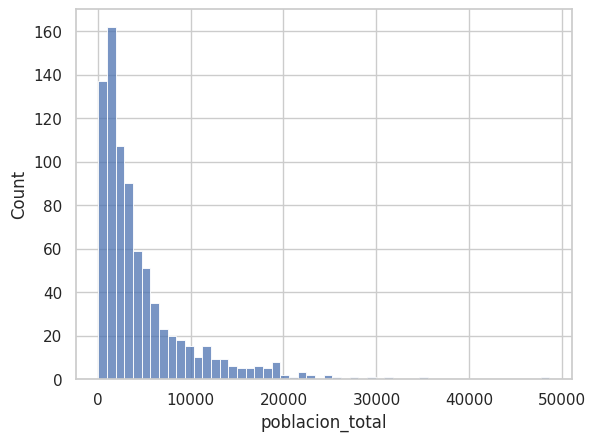

In [372]:
sns.histplot(df_null_urbano, x='poblacion_total'); 

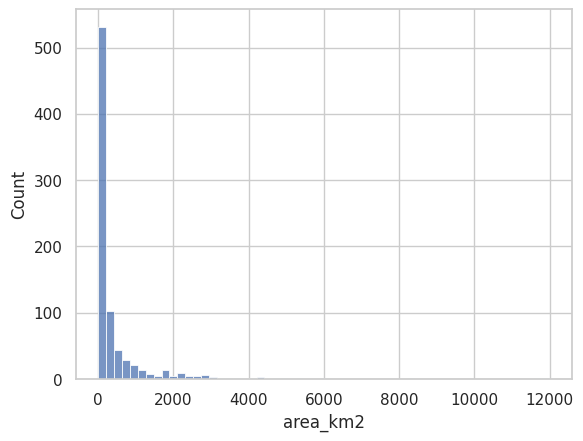

In [373]:
sns.histplot(df_null_urbano, x='area_km2'); 

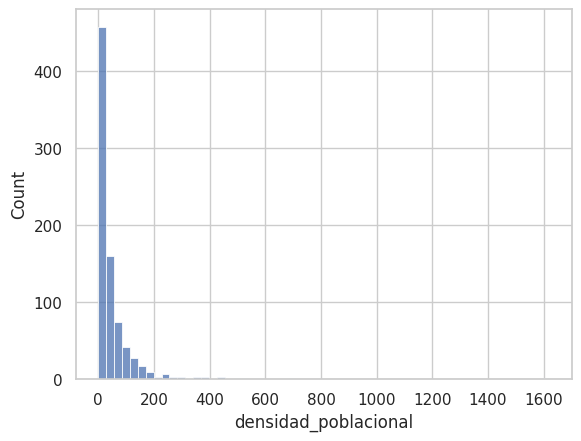

In [374]:
sns.histplot(df_null_urbano['densidad_poblacional']); 

In [375]:
df_null_urbano[['poblacion_total', 'area_km2', 'densidad_poblacional']].describe()

,poblacion_total,area_km2,densidad_poblacional
count,811.000000,811.000000,811.000000
mean,4641.246609,440.245319,46.957492
std,5201.350529,981.378749,86.710639
min,81.000000,2.214071,0.105464
25%,1372.000000,52.607939,8.194312
50%,2846.000000,123.478805,23.572472
75%,5758.000000,351.707086,54.191170
max,48583.000000,11987.599911,1619.937679


La columna `zona_metropolitana` indica si un municipio es una zona urbana (1). Verifiquemos la cantidad de municipios con `poblacion_urbana` nula que son de tipo urbano (1): 

In [376]:
df_null_urbano['zona_metropolitana'].value_counts()

zona_metropolitana
0    808
1      3
Name: count, dtype: int64

Los datos anteriores muestran el siguiente comportamiento: 

- Los municipios precentan baja poblacion total (mediana \~2800 habitantes)
- Baja densidad poblacional (mediana \~23 habitantes por $\text{km}^2$)
- Todos los registros pertenecen a municipios fuera de zonas metropolitanas
- Incluso los municipios con mayor población presentan densidades muy bajas, indicando población dispersa

Estos resultados son consistentes con municipios predominantemente rurales, donde la poblacion urbana es inexistente. 

Con lo anterior, tomamos la desición de imputar las variables `poblacion_urbano`, `prob_urbano` a 0. 

In [377]:
missing_transformations['imputation_zero'] = ['poblacion_urbano', 'prop_urbano']

## Data Types

Conviene clasificar las variables de acuerdo a su naturaleza:

- Variable objetivo: `tasa_delitos`

- Numéricas continuas
  - `indice_marginacion_normalizado_2020`
  - `porcentaje_analfabetismo`
  - `porcentaje_sin_agua_entubada`
  - `porcentaje_viviendas_hacinamiento`
  - `fn_*`
  - `poblacion_urbano`
  - `prop_urbano`
  - `densidad_poblacional`
  - `poblacion_total`
  - `area_km2`
  - `total_delitos`
  - `densidad_poblacional`
  - `lag_delitos`
  - `lag_marginacion`
  - `distancia_frontera`
  - `distancia_zm`

- Geométricas
    - `geometry` 

- Binarias
    - `zona_metropolitana`
    - `es_frontera`

- Categoricas
  - `region` (one-hot encoding)}

- Indicadoras
    - `cvegeo`
    - `nomgeo`

Con lo anterior, lo apropiado es definir las features por grupos y eliminar aquellas que son redundantes o bien, que no serán utilizadas en el modelado de regresión. 

Las columnas `cvegeo` y `nomgeo` son indicadores, por lo que no serán utilizadas.

In [378]:
ids = ['cvegeo', 'nomgeo']

La columna `año` será de utilidad en caso de querer analizar la tendencia temporal de la tasa de delitos. 

In [379]:
time = ['año']

La variable objetivo: 

In [380]:
target = ['tasa_delitos']

Las variables binarias: 

In [381]:
binary = ['zona_metropolitana', 'es_frontera']

Las variables catogericas:

In [382]:
categorical = ['region']  # one-hot encoding

Las variables numéricas: 

In [383]:
numerical = [
    'indice_marginacion_normalizado_2020', 
    'porcentaje_analfabetismo', 
    'porcentaje_sin_agua_entubada', 
    'porcentaje_viviendas_hacinamiento', 
    'fn_pobreza_porcentaje', 
    'fn_pobreza_extrema_porcentaje', 
    'fn_vulnerable_ingresos_porcentaje', 
    'fn_carencia_seguridad_social_porcentaje', 
    'prop_urbano', 
    'densidad_poblacional',
    'lag_delitos',
    'lag_marginacion',
    'distancia_frontera',
    'distancia_zm'
]

Nótese que se han eliminado las variables: 

- `total_delitos`: genera redundancia con `tasa_delitos`
- `fn_poblacion`: genera redundancia con `poblacion_total`
- `poblacion_urbano`: genera redundancia con `prop_urbano`
- `poblacion_total`, `area_km2`: generan redundancia con `densidad_poblacional`

## Features

A continuación analizamos las features que componen al dataset de manera individual.

Definimos una variable auxiliar para registrar las transformaciones necesarias en cada feature: 

In [29]:
feature_transformations = {}

### Categorical

El dataset inclye variables categoricas binarias y multiclase. 

`region` es una variable multiclase que reprecenta la región geográfica del país. 

In [30]:
df[categorical].describe()

,region
count,26038
unique,8
top,sur
freq,7434


In [31]:
df[categorical].value_counts()

region      
sur             7434
centro-sur      6604
sureste         3932
occidente       3586
centro-norte    1188
norte           1155
noroeste        1105
noreste         1034
Name: count, dtype: int64

Esta variable se compone de 8 clases, por lo que será necesario convertir a variables numéricas. Usaremos la técnica One-Hot Encoding. 

In [32]:
feature_transformations['one_hot_encoding'] = ['region']

#### Binary

Las features binarias: 

In [33]:
df[binary].value_counts()

zona_metropolitana  es_frontera
0                   0              22467
1                   0               2834
0                   1                660
1                   1                 77
Name: count, dtype: int64

Estas features no ocupan transformación alguna, ya que se encuentran en reprecentación numérica. 

### Numerical

Analizaremos las features numériacs con el objetivo de identificar presencia de outliers y distribuciones sesgadas. 

Dado que el dataset corresponde a un panel a nivel municipio-año, donde cada observación representa un municipio de México en un año determinado, las features son constantes a través de los años. Por lo tanto, consideraremos un solo año en el análisis univariado. 

In [34]:
df_num = (
    df
        .query('año == 2020')
        .loc[:, numerical]
)

In [35]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2463 entries, 838 to 839
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   indice_marginacion_normalizado_2020      2463 non-null   float64
 1   porcentaje_analfabetismo                 2463 non-null   float64
 2   porcentaje_sin_agua_entubada             2463 non-null   float64
 3   porcentaje_viviendas_hacinamiento        2463 non-null   float64
 4   fn_pobreza_porcentaje                    2462 non-null   float64
 5   fn_pobreza_extrema_porcentaje            2462 non-null   float64
 6   fn_vulnerable_ingresos_porcentaje        2462 non-null   float64
 7   fn_carencia_seguridad_social_porcentaje  2462 non-null   float64
 8   prop_urbano                              1654 non-null   float64
 9   densidad_poblacional                     2463 non-null   float64
 10  lag_delitos                              2463 non-nu

Por completez, aplicamos las transoformaciones mencionadas anteriormente: 

In [36]:
columns_fn = [
    'fn_pobreza_porcentaje', 
    'fn_pobreza_extrema_porcentaje',
    'fn_vulnerable_ingresos_porcentaje', 
    'fn_carencia_seguridad_social_porcentaje'
]

df_num[columns_fn] = (
    df_num[columns_fn].fillna(
        df_num[columns_fn].median()
    )
)

df_num['prop_urbano'] = df_num['prop_urbano'].fillna(0)

In [37]:
df_num.info(); 

<class 'pandas.core.frame.DataFrame'>
Index: 2463 entries, 838 to 839
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   indice_marginacion_normalizado_2020      2463 non-null   float64
 1   porcentaje_analfabetismo                 2463 non-null   float64
 2   porcentaje_sin_agua_entubada             2463 non-null   float64
 3   porcentaje_viviendas_hacinamiento        2463 non-null   float64
 4   fn_pobreza_porcentaje                    2463 non-null   float64
 5   fn_pobreza_extrema_porcentaje            2463 non-null   float64
 6   fn_vulnerable_ingresos_porcentaje        2463 non-null   float64
 7   fn_carencia_seguridad_social_porcentaje  2463 non-null   float64
 8   prop_urbano                              2463 non-null   float64
 9   densidad_poblacional                     2463 non-null   float64
 10  lag_delitos                              2463 non-nu

Definimos una función auxiliar para plotear el histograma y el boxplot de una feature.  

In [38]:
def plot_hist_box(series):
    plt.figure()

    # Hist
    plt.hist(series, bins=30)
    plt.xlabel('Values')
    plt.ylabel('Frecuency')
    plt.show()

    # Boxplot
    plt.figure()
    plt.boxplot(series, vert=True)
    plt.ylabel('Values')
    plt.show()

Definimos una función auxliar para mostrar la proporcion de registros en zona outlier: 

In [39]:
def percentage_outliers(s):
    # Quartiles
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # outliers boundries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # identify outliers
    outliers = s[(s < lower_bound) | (s > upper_bound)]

    percentage = (len(outliers) / len(s)) * 100

    print(f"Percentage of outliers: {percentage:.2f}%")

#### `'indice_marginacion_normalizado_2020'`

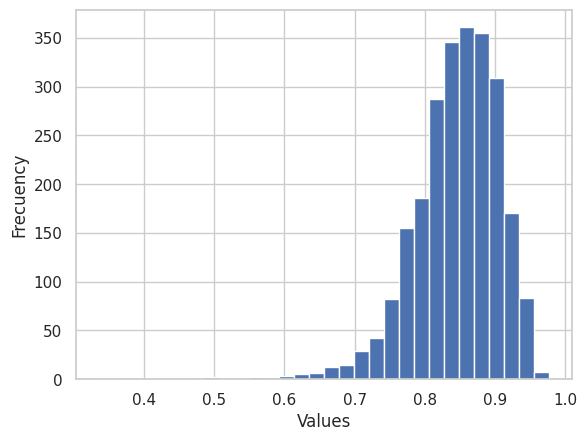

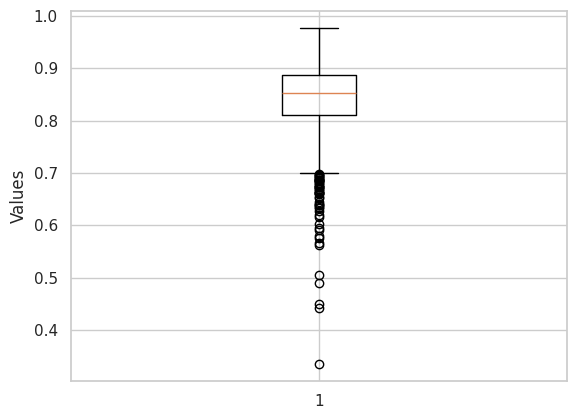

In [40]:
plot_hist_box(df_num['indice_marginacion_normalizado_2020'])

In [41]:
percentage_outliers(df['indice_marginacion_normalizado_2020'])

Percentage of outliers: 2.11%


- Variable de tipo proporcion [0,1']
- Presencia moederada de outliers
- Distribución sesgada a la izquierda

#### `'porcentaje_analfabetismo',`

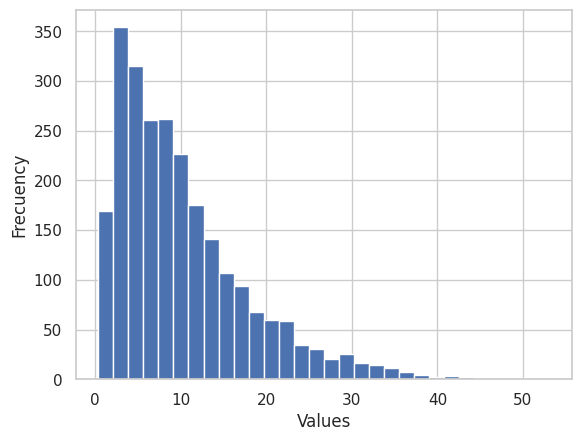

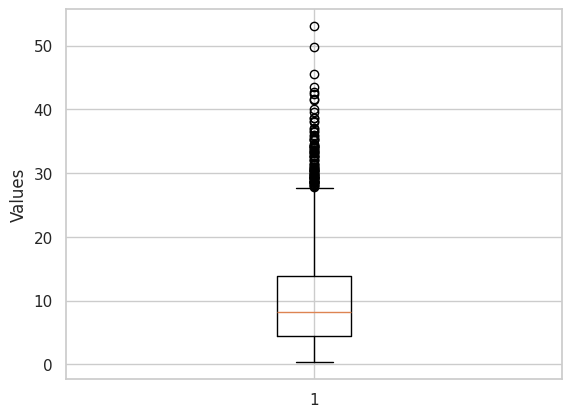

Percentage of outliers: 3.78%


In [42]:
plot_hist_box(df_num['porcentaje_analfabetismo'])
percentage_outliers(df_num['porcentaje_analfabetismo'])

- Variable de tipo proporcion [0,100]
- Precencia moderada de outliers
- Alto sesgo a la derecha

#### `'porcentaje_sin_agua_entubada'`

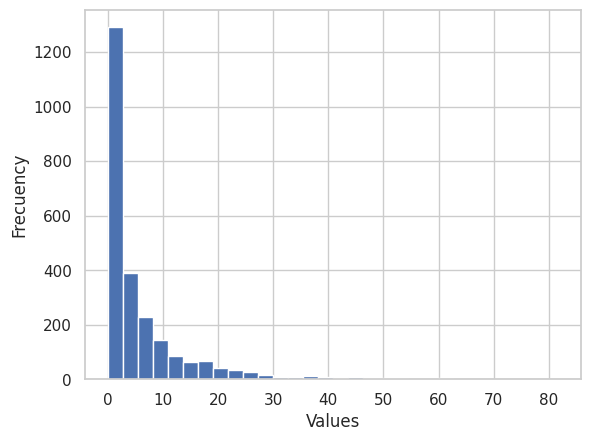

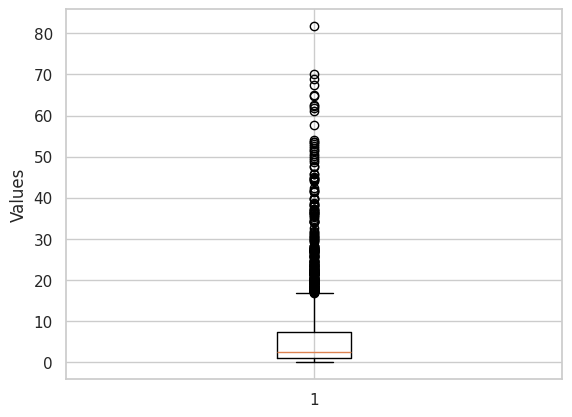

Percentage of outliers: 9.99%


In [43]:
plot_hist_box(df_num['porcentaje_sin_agua_entubada'])
percentage_outliers(df_num['porcentaje_sin_agua_entubada'])

- Variable de tipo proporcion [0,100]
- Precencia alta de outliers
- Alto sesgo a la derecha

#### `'porcentaje_viviendas_hacinamiento',`

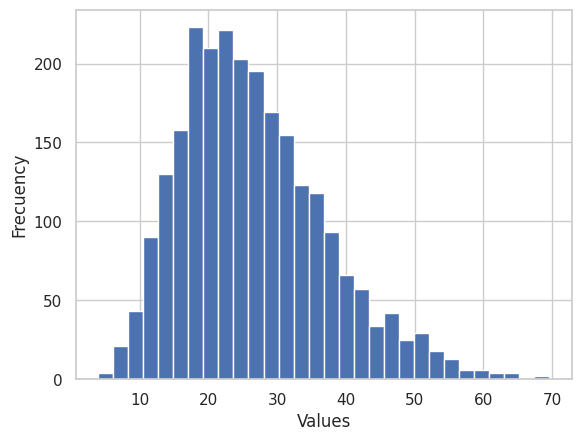

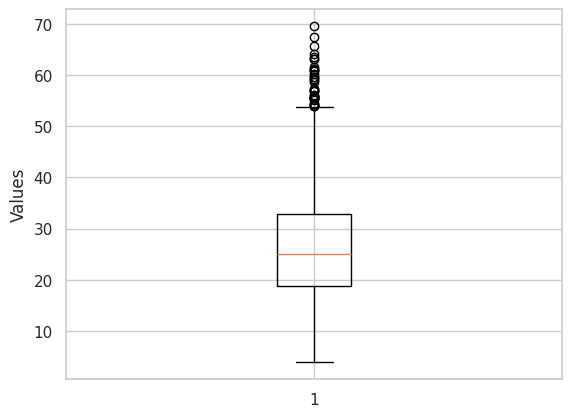

Percentage of outliers: 1.58%


In [44]:
plot_hist_box(df_num['porcentaje_viviendas_hacinamiento'])
percentage_outliers(df_num['porcentaje_viviendas_hacinamiento'])

- Variable de tipo proporcion [0,100]
- Precencia baja de outliers
- sesgo moderado a la derecha

#### `'fn_pobreza_porcentaje'`

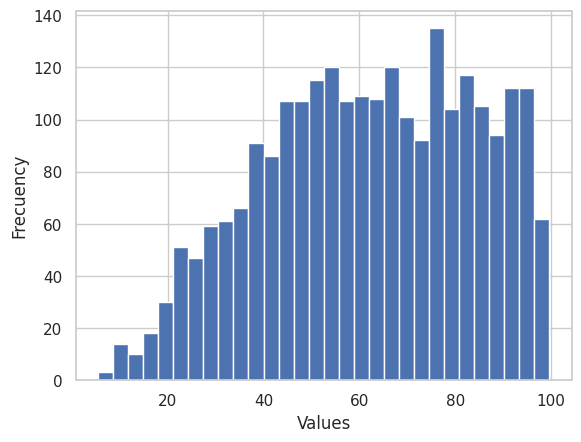

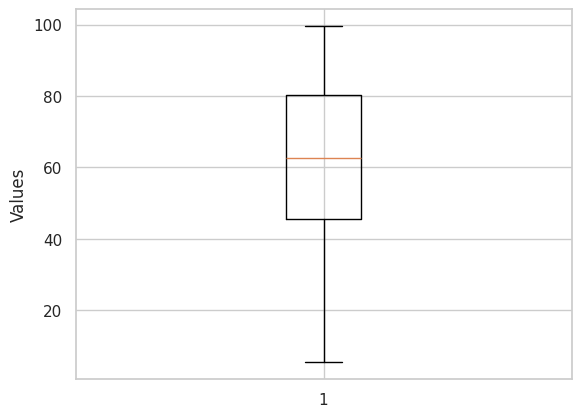

Percentage of outliers: 0.00%


In [45]:
plot_hist_box(df_num['fn_pobreza_porcentaje'])
percentage_outliers(df_num['fn_pobreza_porcentaje'])

- Variable de tipo proporcion [0,100]
- Precencia nula de outliers
- Distribución poco sesgada a la izquierda

#### `'fn_vulnerable_ingresos_porcentaje'`

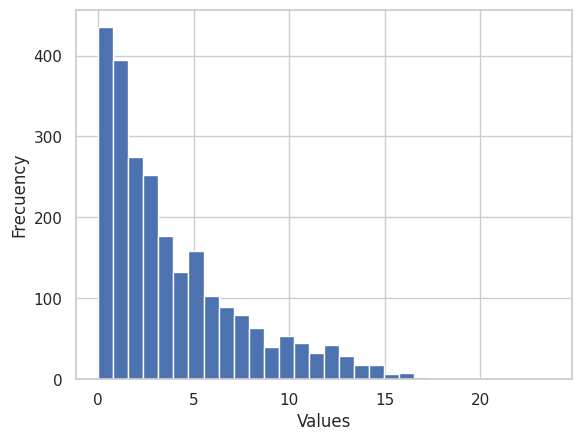

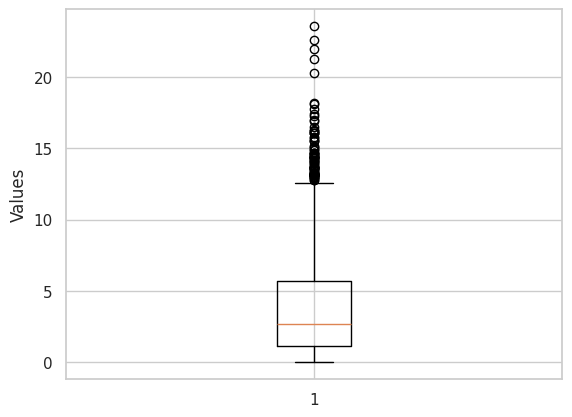

Percentage of outliers: 3.45%


In [46]:
plot_hist_box(df_num['fn_vulnerable_ingresos_porcentaje'])
percentage_outliers(df_num['fn_vulnerable_ingresos_porcentaje'])

- Variable de tipo proporcion [0,100]
- Precencia moderada de outliers
- Sezgo alto a la derecha

#### ` 'fn_carencia_seguridad_social_porcentaje'`

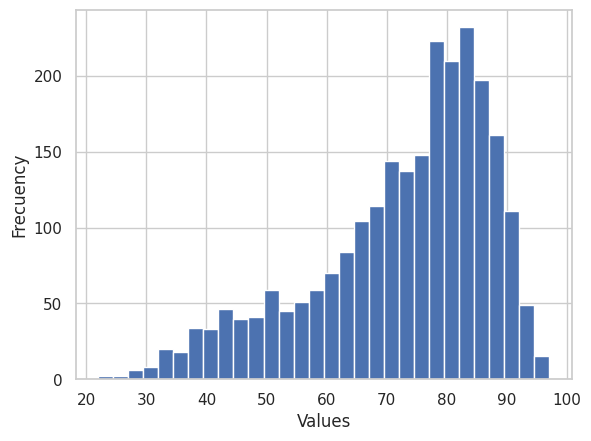

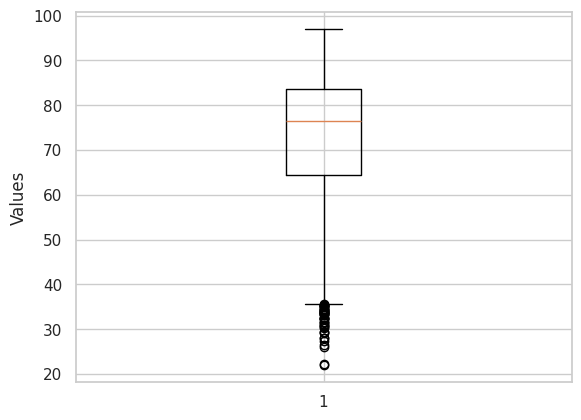

Percentage of outliers: 1.91%


In [47]:
plot_hist_box(df_num['fn_carencia_seguridad_social_porcentaje'])
percentage_outliers(df_num['fn_carencia_seguridad_social_porcentaje'])

- Variable de tipo proporcion [0,100]
- Precencia baja de outliers
- Sezgo alto a la izquerda

#### ` 'prop_urbano'`

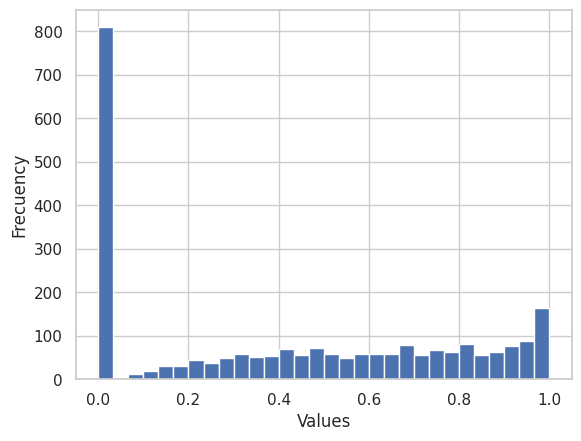

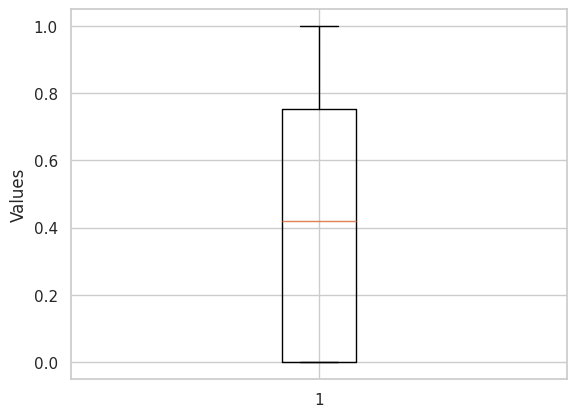

Percentage of outliers: 0.00%


In [48]:
plot_hist_box(df_num['prop_urbano'])
percentage_outliers(df_num['prop_urbano'])

- Variable de tipo proporcion [0,1]
- Precencia nula de outliers

#### `'densidad_poblacional'` 

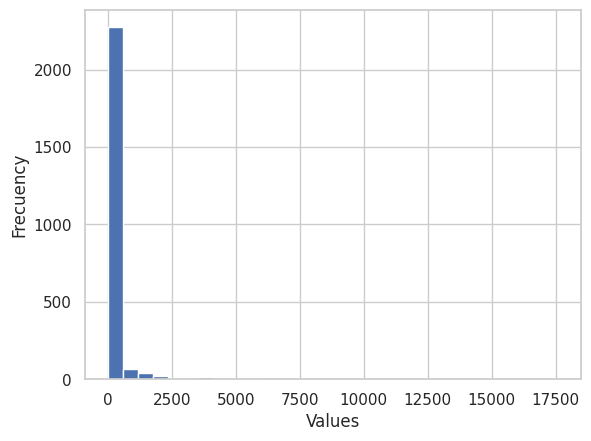

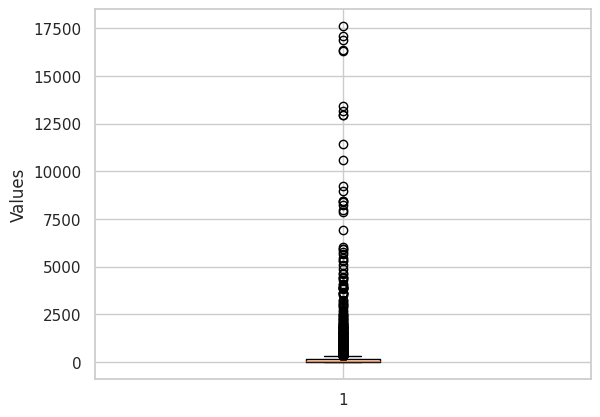

Percentage of outliers: 12.59%


In [49]:
plot_hist_box(df_num['densidad_poblacional'])
percentage_outliers(df_num['densidad_poblacional'])

- Variable de tipo continua
- Precencia alta de outliers
- Sezgo alto a la derecha

Dado que la distribución es de tipo continua, sesgada a la derecha y posee una cantidad moderada de outlers, lo conveniente es aplicarle una transformación de tipo logaritmica. 

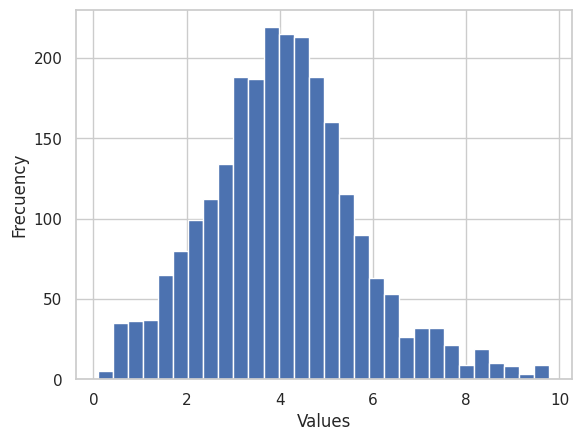

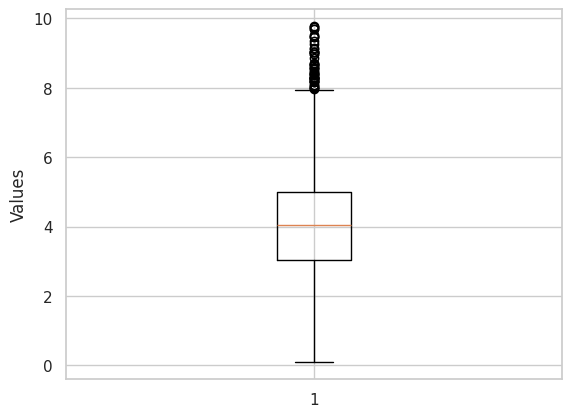

Percentage of outliers: 2.27%


In [50]:
log_dens_pob = np.log1p(df_num['densidad_poblacional'])
plot_hist_box(log_dens_pob)
percentage_outliers(log_dens_pob)

Observamos que la transformación logaritmica centra la distribución y además, reduce considerablemente la proporcion de outliers. Por lo tanto, consideraremos una transformación en esta feature. 

In [51]:
feature_transformations['log1p'] = ['densidad_poblacional']

#### `'distancia_frontera'`

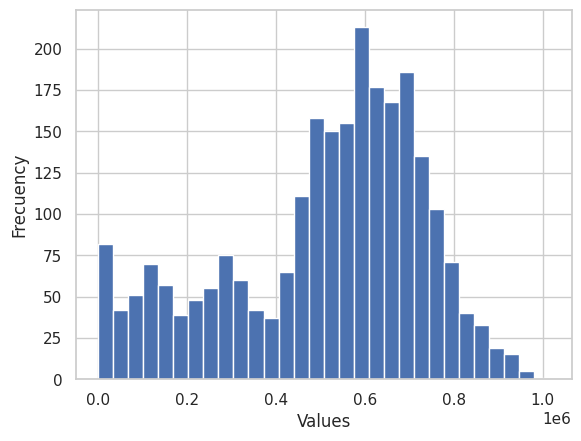

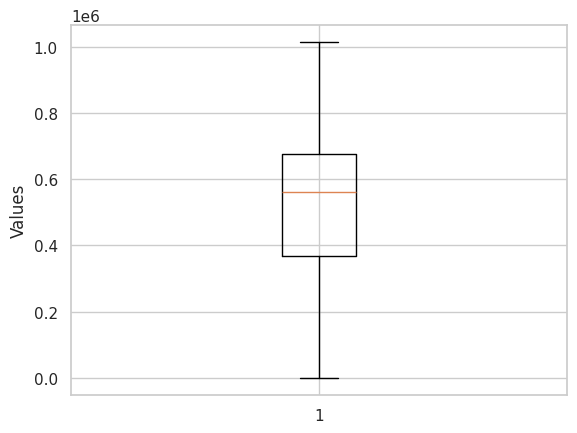

Percentage of outliers: 0.00%


In [52]:
plot_hist_box(df_num['distancia_frontera'])
percentage_outliers(df_num['distancia_frontera'])

#### `'distancia_zm'`

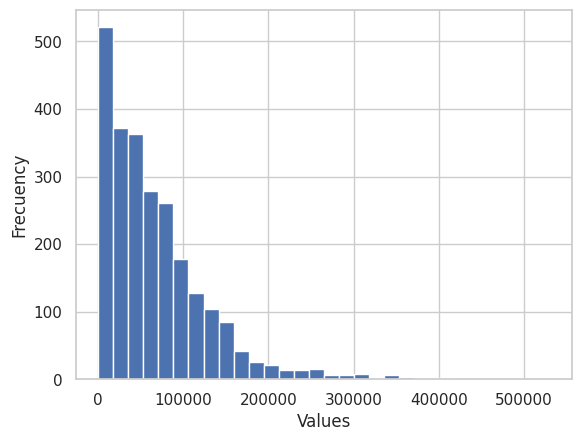

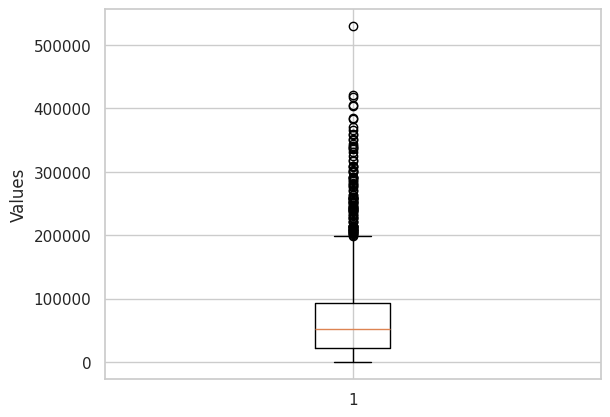

Percentage of outliers: 4.06%


In [53]:
plot_hist_box(df_num['distancia_zm'])
percentage_outliers(df_num['distancia_zm'])

## Target (`tasa_delitos`)

La distribución de la variable objetivo: 

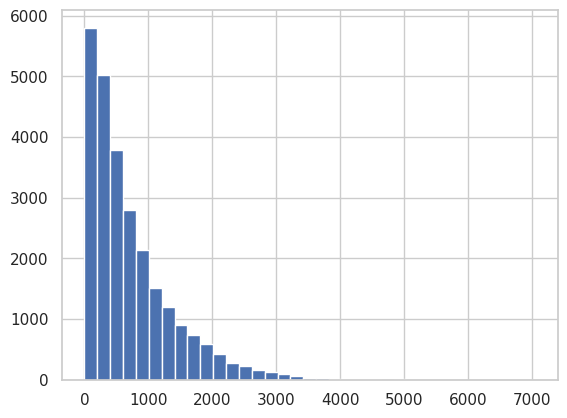

In [54]:
df['tasa_delitos'].hist(bins=35); 

In [55]:
percentage_outliers(df['tasa_delitos'])

Percentage of outliers: 4.59%


La variable es de tipo continua, presenta alto sezgo a la derecha. Consideremos su transformación logarigmica: 

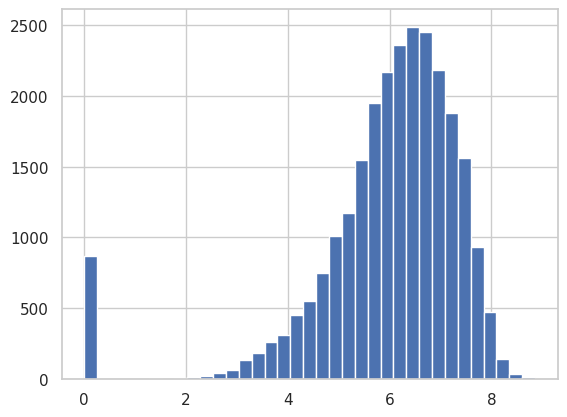

In [56]:
log_target = np.log1p(df['tasa_delitos'])
log_target.hist(bins=35); 

In [57]:
percentage_outliers(log_target)

Percentage of outliers: 4.17%


Observamos que la transformación logaritmica centra la distribución y además, reduce la proporcion de outliers. Por lo tanto, consideraremos una transformación logaritmica de la variable objetivo. 

## Correlation

A continuación realizamos el análisis de correlación entre las features y la variable objetivo. 

Visualizamos la matriz de correlación features-target: 

In [58]:
corr = df.corr(numeric_only=True)['tasa_delitos'].sort_values()
corr[numerical]

indice_marginacion_normalizado_2020        0.518582
porcentaje_analfabetismo                  -0.465092
porcentaje_sin_agua_entubada              -0.165438
porcentaje_viviendas_hacinamiento         -0.421115
fn_pobreza_porcentaje                     -0.514937
fn_pobreza_extrema_porcentaje             -0.437069
fn_vulnerable_ingresos_porcentaje          0.454339
fn_carencia_seguridad_social_porcentaje   -0.461245
prop_urbano                                0.336094
densidad_poblacional                       0.357379
lag_delitos                                0.736910
lag_marginacion                            0.473201
distancia_frontera                         0.054304
distancia_zm                              -0.164124
Name: tasa_delitos, dtype: float64

Se identifican dos patrones principales: 

1. Variables socioeconómicas asociadas a la marginación (pobreza, analfabetismo, carencias) presentan correlación negativa con la tasa de delitos.
2. Variables asociadas a la urbanizacion (densidad, proporcion urbana) presentan correlación positiva.

Estos resultados sugieren que la incidencia delictiva está más relacionada con el grado de urbanización que con las condiciones de pobreza.

Es posible que los municipios presenten menor incidencia delictiva, mientras que los municipios urbanos concentren la mayor actividad delictiva. 

### Scatterplots

La correlación entre las diferentes features y la variable objetivo no es sinónimo de linealidad

`'indice_marginacion_normalizado_2020'`

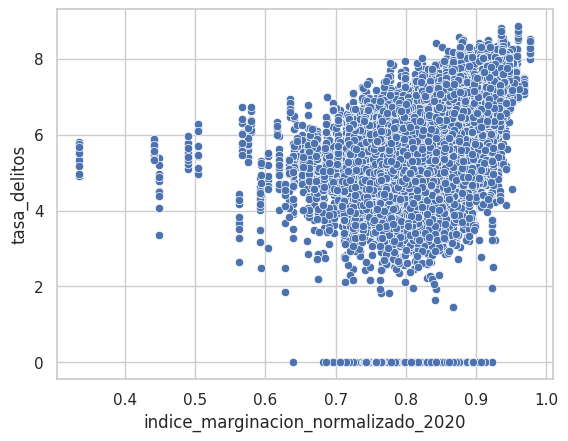

In [77]:
sns.scatterplot(x=df['porcentaje_analfabetismo'], y=np.log1p(df['tasa_delitos'])); 

`'porcentaje_analfabetismo'`

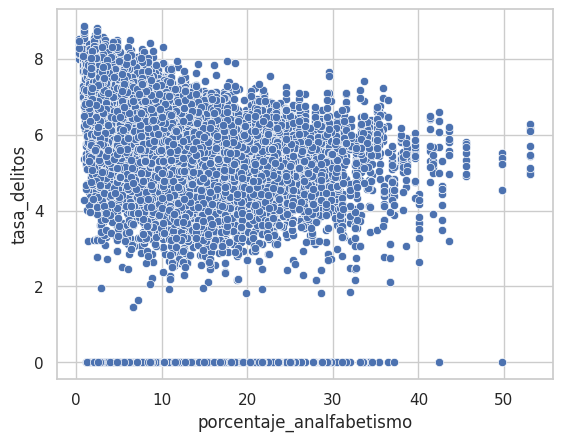

In [78]:
sns.scatterplot(x=df['porcentaje_analfabetismo'], y=np.log1p(df['tasa_delitos'])); 

`'porcentaje_sin_agua_entubada'`

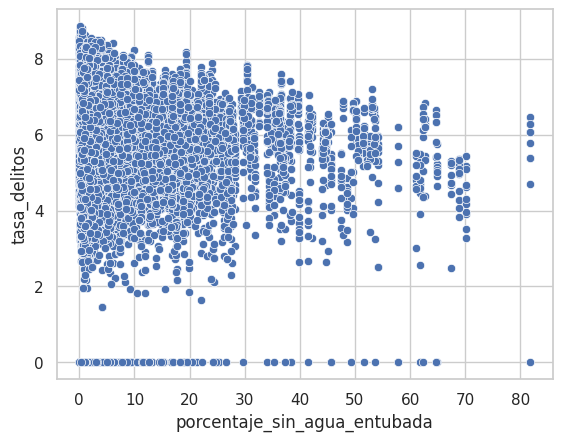

In [79]:
sns.scatterplot(x=df['porcentaje_sin_agua_entubada'], y=np.log1p(df['tasa_delitos'])); 

`'porcentaje_viviendas_hacinamiento'`

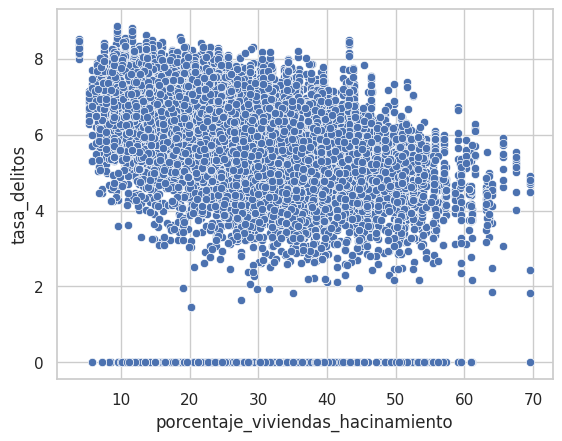

In [80]:
sns.scatterplot(x=df['porcentaje_viviendas_hacinamiento'], y=np.log1p(df['tasa_delitos'])); 

`'fn_pobreza_porcentaje'`

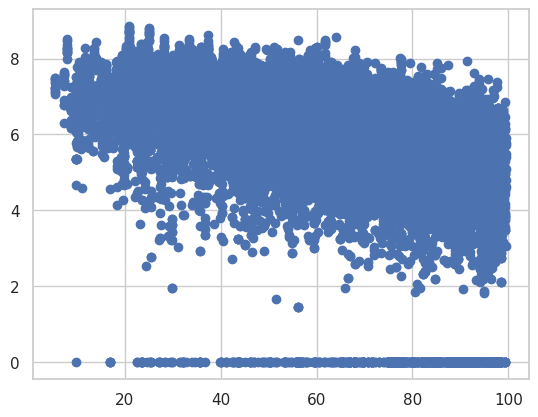

In [88]:
plt.scatter(x=df['fn_pobreza_porcentaje'], y=np.log1p(df['tasa_delitos'])); 

`fn_pobreza_extrema_porcentaje`

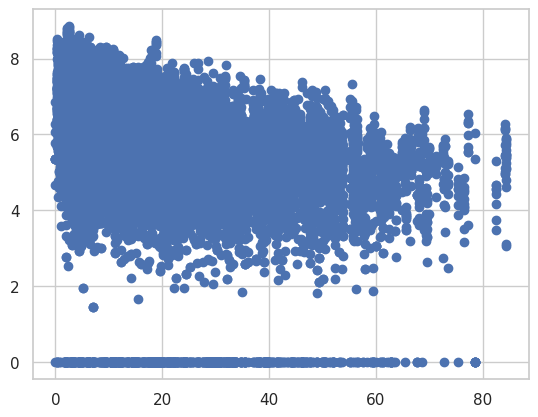

In [87]:
plt.scatter(x=df['fn_pobreza_extrema_porcentaje'], y=np.log1p(df['tasa_delitos'])); 

`'fn_vulnerable_ingresos_porcentaje'`

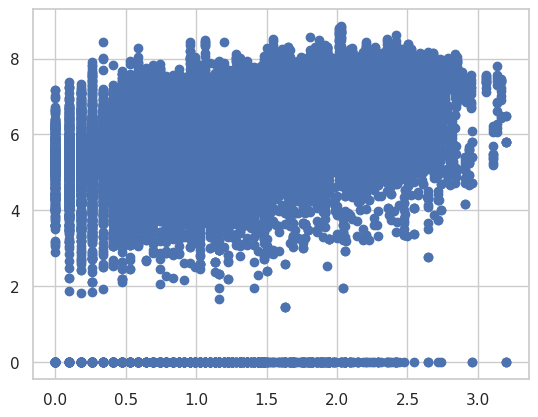

In [97]:
plt.scatter(x=np.log1p(df['fn_vulnerable_ingresos_porcentaje']), y=np.log1p(df['tasa_delitos'])); 

`'fn_carencia_seguridad_social_porcentaje'`

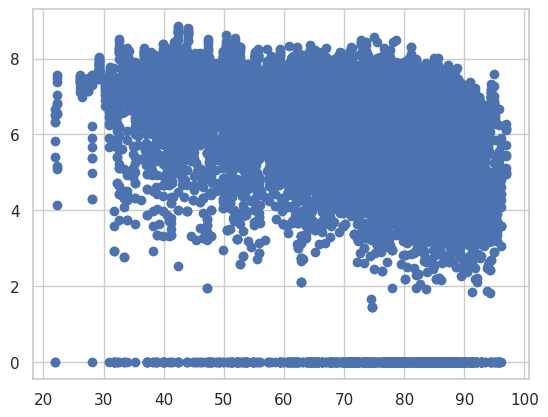

In [91]:
plt.scatter(x=df['fn_carencia_seguridad_social_porcentaje'], y=np.log1p(df['tasa_delitos'])); 

`'prop_urbano'`

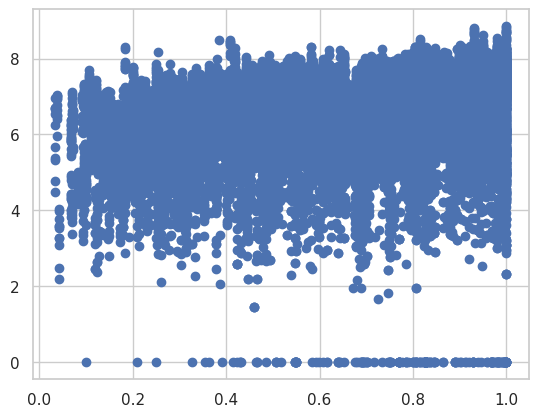

In [92]:
plt.scatter(x=df['prop_urbano'], y=np.log1p(df['tasa_delitos'])); 

`'densidad_poblacional'`

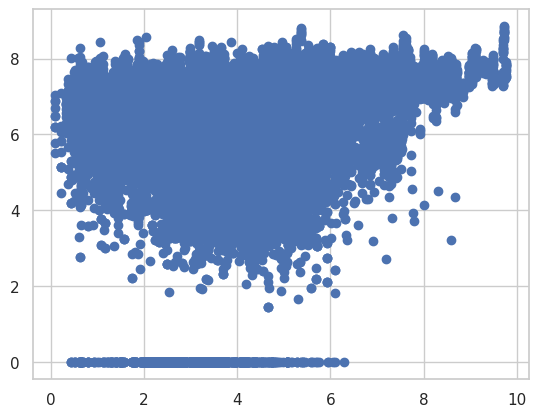

In [99]:
plt.scatter(x=np.log1p(df['densidad_poblacional']), y=np.log1p(df['tasa_delitos'])); 

Los scatterplots anteriores podemos resumirlos como sigue: 

- 

## Collinearity

A continuación analizamos la coolinealidad de las features numéricas.

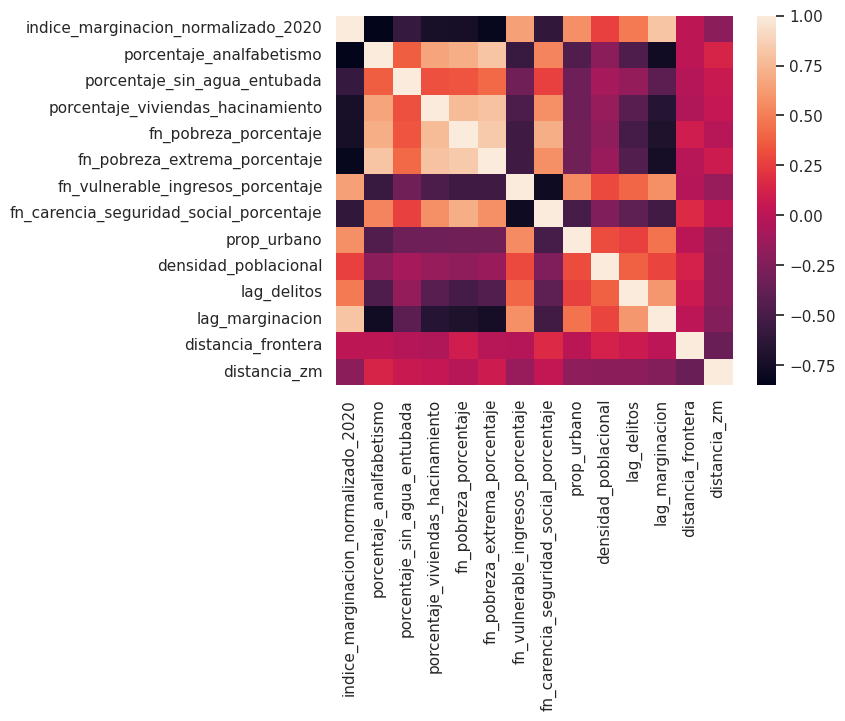

In [101]:
sns.heatmap(df[numerical].corr()); 

El heatmap de correlación muestra un gradiente predominantemente rojo, lo que sugiere una alta correlación entre algunas de las features. En particular, las features de marginación, pobreza, carencias y rezago social muestran coeficientes en el rango 0.7-0.8 y por lo tanto explican la misma información.

Para confirmar los resultados anteriores, computamos el VIF (Variance Inlfation Factor): 

In [106]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [122]:
X = df[numerical]

X['prop_urbano'] = X['prop_urbano'].fillna(0)

X = X.dropna()

/tmp/ipykernel_63789/1051335473.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['prop_urbano'] = X['prop_urbano'].fillna(0)


In [125]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)


                                    feature         VIF
0       indice_marginacion_normalizado_2020  817.490585
1                  porcentaje_analfabetismo    9.034194
2              porcentaje_sin_agua_entubada    1.964390
3         porcentaje_viviendas_hacinamiento   23.589664
4                     fn_pobreza_porcentaje   52.040030
5             fn_pobreza_extrema_porcentaje   14.088360
6         fn_vulnerable_ingresos_porcentaje    8.225462
7   fn_carencia_seguridad_social_porcentaje  107.214073
8                               prop_urbano    4.359846
9                      densidad_poblacional    1.365882
10                              lag_delitos    5.237667
11                          lag_marginacion  900.793437
12                       distancia_frontera    7.544231
13                             distancia_zm    2.577428


El vif muestra problemas de correlación serios: 

- marginación &rarr; 817
- lag_marginacion &rarr; 900
- carencia_seguridad_social &rarr; 107
- pobreza &rarr; 52
- hacintamiento &rarr; 23

Las variables consideradas miden exactamente lo mismo.

## Conclusion

El EDA permitió identificar patrones importantes, así como limitaciones del dataset. 

### Calidad de datos y valores faltantes

Se identificaron valores nulos en distintas variables. 

Las variables `fn_*` presentan una proporción de valores faltantes menor al 0.1\%, por lo que la imputación simple mediante la mediana es lo adecuado.

Por otro lado, las variables `prop_urbano` (derivada de `poblacion_urbano`) presenta aproximadamente un 30\% de valores faltantes. El análisis de estos casos mostró que corresponden a municipios con característicsa rurales: baja densidad poblacional, baja población y la no pertenencia a zonas metropolitanas. Esto indica que el missing no es aleatorio. En consecuencia, lo correcto es imputar estos valores como 0, ya que significa que los registros nulos corresponden con municipios rurales.

### Tipos de variables y depuración

Se clasificaron las variables en:

* Variables numéricas continuas (socioeconómicas y demográficas)
* Variables binarias (`zona_metropolitana`, `es_frontera`)
* Variable categórica (`region`)

Se excluyeron variables identificadoras (`cvegeo`, `nomgeo`) y variables redundantes o derivadas que introducen colinealidad (`total_delitos`, `fn_poblacion`, `poblacion_urbano`, `area_km2`).

### Distribución y transformaciones

Se observó que múltiples variables presentan distribuciones altamente sesgadas, particularmente aquellas relacionadas con proporciones y densidad.

Se propone:

* Aplicar transformación logarítmica (`log1p`) a `densidad_poblacional`
* Aplicar transformación logarítmica a la variable objetivo `tasa_delitos`

Estas transformaciones permiten estabilizar la varianza y reducir la influencia de outliers.

### Relación con la variable objetivo

El análisis de scatterplots reveló patrones no lineales entre las variables predictoras y la variable objetivo:

* Variables de marginación y pobreza presentan relaciones negativas con saturación
* Variables de urbanización muestran relaciones positivas más estables
* Se observa heterocedasticidad en varias relaciones (patrones tipo embudo)

Estos resultados sugieren que las relaciones no son estrictamente lineales.

### Correlación

El análisis de correlación muestra que:

* Variables de marginación: correlación negativa con la tasa de delitos
* Variables de urbanización: correlación positiva

Este resultado no debe interpretarse como una relación causal directa. Es probable que la relación negativa observada entre pobreza y delitos sea influenciada por el grado de urbanización, dado que los municipios urbanos presentan mayor incidencia delictiva reportada y menor marginación relativa.

### Multicolinealidad

El análisis de VIF mostró niveles elevados de multicolinealidad entre variables socioeconómicas, particularmente aquellas asociadas a marginación y pobreza.

Esto indica que múltiples variables están capturando una misma dimensión, lo que puede afectar la estabilidad de los coeficientes en modelos lineales.

Para mitigar este problema se considerará:

* Reducción del número de variables redundantes
* Uso de regularización (Ridge / Lasso)

### Implicaciones en el modelado

Aunque se identificaron evidencias claras de no linealidad, en esta etapa se prioriza la construcción de modelos interpretables (Regresión Lineal, Ridge y Lasso).

Estos modelos deben entenderse como una aproximación inicial que permite analizar relaciones globales entre variables, aun cuando no capturen completamente la complejidad del fenómeno.

Modelos más complejos (Random Forest, Gradient Boosting) serán utilizados posteriormente para capturar relaciones no lineales y mejorar el desempeño predictivo.

In [356]:
1

1